In [7]:
import numpy as np
import matplotlib.pyplot as plt

S0 = 100
mu = 0.08
sigma = 0.20

T = 1
n_steps = 252
n_paths = 10000

dt = T / n_steps

In [8]:
z = np.random.normal(0, 1, size=(n_steps, n_paths))
print(z.shape)

growth_factors = np.exp((mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * z)
print(growth_factors.shape)

prices = S0 * np.cumprod(growth_factors, axis=0)

initial_prices = np.full((1, n_paths), S0)

prices = np.vstack((initial_prices, prices))

print(prices.shape)

(252, 10000)
(252, 10000)
(253, 10000)


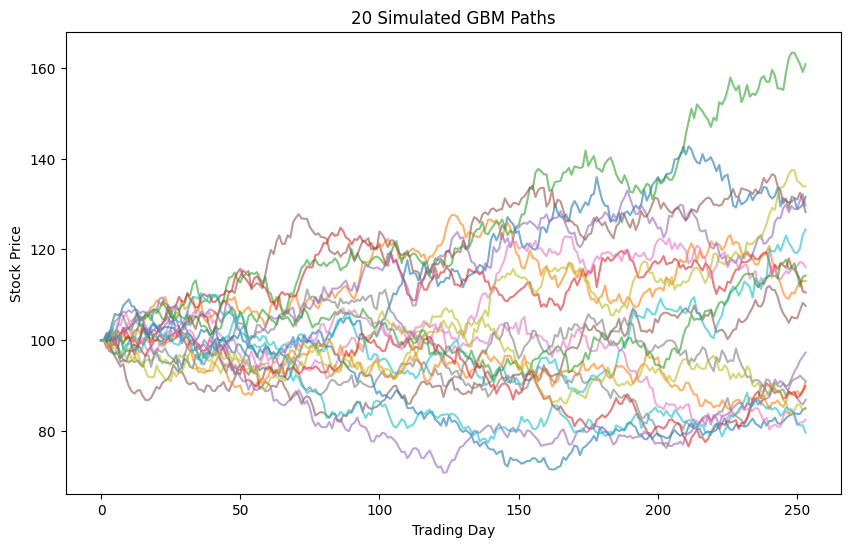

In [9]:
np.full((1, 10000), 100)

prices = np.vstack((initial_prices, prices))

plt.figure(figsize=(10, 6))

for i in range(20):
    plt.plot(prices[:, i], alpha=0.6)

plt.xlabel("Trading Day")
plt.ylabel("Stock Price")
plt.title("20 Simulated GBM Paths")
plt.show()

(10000,)


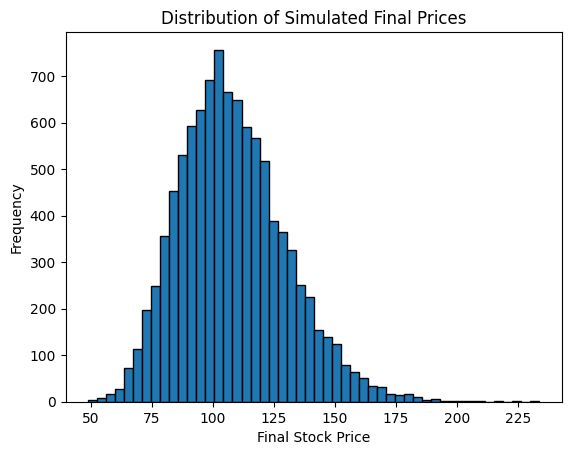

In [10]:
final_prices = prices[-1, :]
print(final_prices.shape)

plt.hist(
    final_prices,
    bins=50,
    edgecolor="black"
)

plt.xlabel("Final Stock Price")
plt.ylabel("Frequency")
plt.title("Distribution of Simulated Final Prices")
plt.show()

In [11]:
mean_final = np.mean(final_prices)
median_final = np.median(final_prices)

print("Mean final price:", mean_final)
print("Median final price:", median_final)

percentiles = np.percentile(final_prices, [5, 25, 50, 75, 95])

print(percentiles)

Mean final price: 108.13884826203243
Median final price: 106.00199117561601
[ 75.50827431  92.49735458 106.00199118 121.46716283 147.47122369]


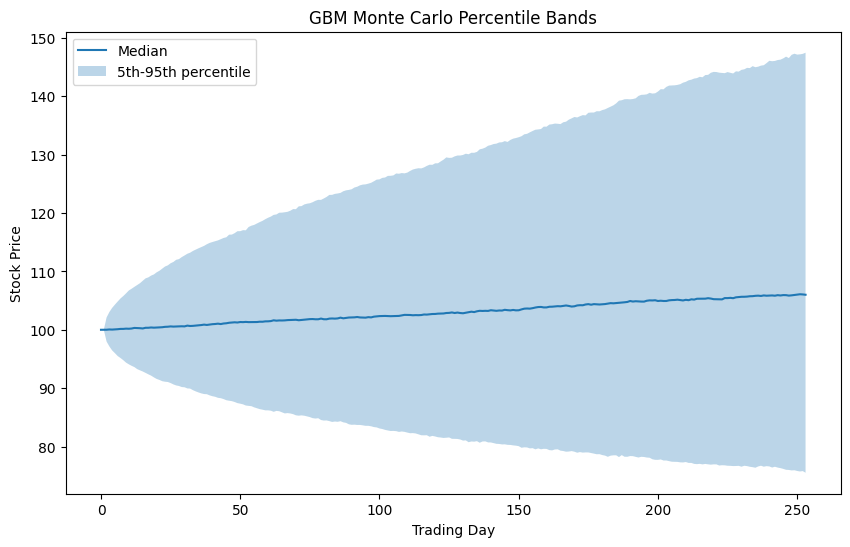

In [12]:
p5 = np.percentile(prices, 5, axis=1)
p50 = np.percentile(prices, 50, axis=1)
p95 = np.percentile(prices, 95, axis=1)

days = np.arange(prices.shape[0])

plt.figure(figsize=(10, 6))

plt.plot(days, p50, label="Median")
plt.fill_between(
    days,
    p5,
    p95,
    alpha=0.3,
    label="5th-95th percentile"
)

plt.xlabel("Trading Day")
plt.ylabel("Stock Price")
plt.title("GBM Monte Carlo Percentile Bands")
plt.legend()
plt.show()